In [222]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy.stats as stats
import scipy.optimize as optimize
import scipy.spatial as spatial
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [223]:
df = pd.read_csv('data/runs/run_20260331_190615_05b7b819/whale_dataset_final.csv')

In [224]:
df.shape

(25727, 23)

In [225]:
df.head(5)

,SIGHTINGDATE,LAT,LON,Presence,SOURCE,SOURCE_DETAIL,PACKAGE_ID,Season,SST_Celsius,Frontal_Value,Chlorophyll_mg_m3,Salinity_PSU,Water_Mass_M_WK,SST_env_source,Chlorophyll_env_source,Frontal_env_source,Salinity_env_source,SST_is_observed,Frontal_is_observed,Chlorophyll_is_observed,Salinity_is_observed,Water_Mass_is_observed,Any_env_missing
0,2002-02-06,41.93,-70.52,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1
1,2002-02-07,41.88,-70.28,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1
2,2002-02-07,42.15,-70.33,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1
3,2002-02-07,42.20,-70.20,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1
4,2002-02-07,42.24,-70.20,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1


In [226]:
df.columns

Index(['SIGHTINGDATE', 'LAT', 'LON', 'Presence', 'SOURCE', 'SOURCE_DETAIL',
       'PACKAGE_ID', 'Season', 'SST_Celsius', 'Frontal_Value',
       'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK',
       'SST_env_source', 'Chlorophyll_env_source', 'Frontal_env_source',
       'Salinity_env_source', 'SST_is_observed', 'Frontal_is_observed',
       'Chlorophyll_is_observed', 'Salinity_is_observed',
       'Water_Mass_is_observed', 'Any_env_missing'],
      dtype='str')

In [227]:
df.dtypes

SIGHTINGDATE                   str
LAT                        float64
LON                        float64
Presence                     int64
SOURCE                         str
SOURCE_DETAIL                  str
PACKAGE_ID                     str
Season                         str
SST_Celsius                float64
Frontal_Value              float64
Chlorophyll_mg_m3          float64
Salinity_PSU               float64
Water_Mass_M_WK            float64
SST_env_source                 str
Chlorophyll_env_source         str
Frontal_env_source             str
Salinity_env_source            str
SST_is_observed              int64
Frontal_is_observed          int64
Chlorophyll_is_observed      int64
Salinity_is_observed         int64
Water_Mass_is_observed       int64
Any_env_missing              int64
dtype: object

In [228]:
df.describe()

,LAT,LON,Presence,SST_Celsius,Frontal_Value,Chlorophyll_mg_m3,Salinity_PSU,Water_Mass_M_WK,SST_is_observed,Frontal_is_observed,Chlorophyll_is_observed,Salinity_is_observed,Water_Mass_is_observed,Any_env_missing
count,25727.000000,25727.000000,25727.000000,25254.000000,25125.000000,24887.000000,6244.000000,25170.000000,25727.000000,25727.000000,25727.000000,25727.000000,25727.000000,25727.000000
mean,38.782491,-73.013762,0.485366,13.315490,0.315979,3.237622,34.378304,169.710524,0.981615,0.976600,0.967349,0.242702,0.978350,0.759591
std,5.769412,5.628506,0.499796,7.526038,0.687780,4.949448,2.089795,114.708502,0.134343,0.151172,0.177724,0.428725,0.145542,0.427340
min,24.433130,-85.770000,0.000000,-160.845000,0.000000,0.034057,27.215614,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.390000,-80.890400,0.000000,7.369500,0.000000,0.933938,32.862371,63.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
50%,41.880000,-70.310000,0.000000,13.257610,0.109995,1.811244,34.301190,157.857143,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,42.255530,-69.940000,1.000000,17.685187,0.367766,3.621648,35.944767,248.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,51.690000,-52.680000,1.000000,163.834990,26.145123,99.770515,39.988754,458.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [229]:
df = df[['SIGHTINGDATE', 'LAT', 'LON', 'Presence', 
         # 'SOURCE', 'SOURCE_DETAIL', 'PACKAGE_ID', 
         'Season', 'SST_Celsius', 'Frontal_Value',
       'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK',
       'SST_env_source', 'Chlorophyll_env_source', 'Frontal_env_source', 'Salinity_env_source', 
       'SST_is_observed', 'Frontal_is_observed', 'Chlorophyll_is_observed', 'Salinity_is_observed',
       'Water_Mass_is_observed', 'Any_env_missing']].copy()

In [230]:
df['SIGHTINGDATE'] = pd.to_datetime(df['SIGHTINGDATE'], errors='coerce')
df['SST_Celsius'] = pd.to_numeric(df['SST_Celsius'], errors='coerce')
df['Chlorophyll_mg_m3'] = pd.to_numeric(df['Chlorophyll_mg_m3'], errors='coerce')
df['Salinity_PSU'] = pd.to_numeric(df['Salinity_PSU'], errors='coerce')
df['Water_Mass_M_WK'] = pd.to_numeric(df['Water_Mass_M_WK'], errors='coerce')
df['Frontal_Value'] = pd.to_numeric(df['Frontal_Value'], errors='coerce')
df['Presence'] = pd.to_numeric(df['Presence'], errors='coerce')
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25727 entries, 0 to 25726
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   SIGHTINGDATE             25727 non-null  datetime64[us]
 1   LAT                      25727 non-null  float64       
 2   LON                      25727 non-null  float64       
 3   Presence                 25727 non-null  int64         
 4   Season                   25727 non-null  str           
 5   SST_Celsius              25254 non-null  float64       
 6   Frontal_Value            25125 non-null  float64       
 7   Chlorophyll_mg_m3        24887 non-null  float64       
 8   Salinity_PSU             6244 non-null   float64       
 9   Water_Mass_M_WK          25170 non-null  float64       
 10  SST_env_source           25254 non-null  str           
 11  Chlorophyll_env_source   24887 non-null  str           
 12  Frontal_env_source       25125 non-null  st

In [231]:
df.isna().sum()

SIGHTINGDATE                   0
LAT                            0
LON                            0
Presence                       0
Season                         0
SST_Celsius                  473
Frontal_Value                602
Chlorophyll_mg_m3            840
Salinity_PSU               19483
Water_Mass_M_WK              557
SST_env_source               473
Chlorophyll_env_source       840
Frontal_env_source           602
Salinity_env_source        19483
SST_is_observed                0
Frontal_is_observed            0
Chlorophyll_is_observed        0
Salinity_is_observed           0
Water_Mass_is_observed         0
Any_env_missing                0
dtype: int64

In [232]:
df.duplicated(subset=['SIGHTINGDATE']).sum()

np.int64(19219)

In [233]:
sub = ['SIGHTINGDATE', 'LAT', 'LON', 'Presence', 
        'SST_Celsius', 'Chlorophyll_mg_m3']

# Number of rows with presence = 0 with missing values in the subset of columns
print(df[df['Presence'] == 0][sub].isna().sum())

df = df.dropna(subset=sub).reset_index(drop=True).copy()

# Check for number of rows with Prescence = 1 vs 0
print(df['Presence'].value_counts())


SIGHTINGDATE           0
LAT                    0
LON                    0
Presence               0
SST_Celsius          284
Chlorophyll_mg_m3    586
dtype: int64
Presence
0    12650
1    12224
Name: count, dtype: int64


In [234]:
# Check for near-duplicate locations within same dates
print("=== SPATIAL DUPLICATE ANALYSIS ===")

# Define tolerance for geographic proximity (in degrees)
lat_tol = 0.01  # ~1km at equator
lon_tol = 0.01  # ~1km at equator

total_near_duplicates = 0
dates_with_spatial_duplicates = 0

# Group by date and check for spatial duplicates within each date
for date, group in df.groupby('SIGHTINGDATE'):
    if len(group) > 1:  # Only check dates with multiple entries
        # Calculate pairwise distances
        coords = group[['LAT', 'LON']].values
        n_points = len(coords)

        # Check each pair
        spatial_dups_in_date = 0
        for i in range(n_points):
            for j in range(i+1, n_points):
                lat_diff = abs(coords[i][0] - coords[j][0])
                lon_diff = abs(coords[i][1] - coords[j][1])

                if lat_diff <= lat_tol and lon_diff <= lon_tol:
                    spatial_dups_in_date += 1

        if spatial_dups_in_date > 0:
            dates_with_spatial_duplicates += 1
            total_near_duplicates += spatial_dups_in_date

print(f"Dates with multiple entries: {(df['SIGHTINGDATE'].value_counts() > 1).sum()}")
print(f"Dates with near-duplicate locations (within {lat_tol}° lat/lon): {dates_with_spatial_duplicates}")
print(f"Total near-duplicate location pairs: {total_near_duplicates}")

# Show some examples
print("\nTop 10 dates with most spatial duplicates:")
spatial_dup_counts = []

for date, group in df.groupby('SIGHTINGDATE'):
    if len(group) > 1:
        coords = group[['LAT', 'LON']].values
        n_points = len(coords)

        # Count spatial duplicate pairs for this date
        spatial_dups_in_date = 0
        for i in range(n_points):
            for j in range(i+1, n_points):
                lat_diff = abs(coords[i][0] - coords[j][0])
                lon_diff = abs(coords[i][1] - coords[j][1])

                if lat_diff <= lat_tol and lon_diff <= lon_tol:
                    spatial_dups_in_date += 1

        if spatial_dups_in_date > 0:
            spatial_dup_counts.append((date, len(group), spatial_dups_in_date))

# Sort by number of spatial duplicate pairs (descending)
spatial_dup_counts.sort(key=lambda x: x[2], reverse=True)

# Show top 10
for date, total_entries, spatial_pairs in spatial_dup_counts[:10]:
    print(f"  {date.date()}: {total_entries} entries, {spatial_pairs} spatial duplicate pairs")

=== SPATIAL DUPLICATE ANALYSIS ===
Dates with multiple entries: 4915
Dates with near-duplicate locations (within 0.01° lat/lon): 284
Total near-duplicate location pairs: 827

Top 10 dates with most spatial duplicates:
  2013-04-26: 85 entries, 28 spatial duplicate pairs
  2013-04-29: 65 entries, 24 spatial duplicate pairs
  2017-04-14: 100 entries, 23 spatial duplicate pairs
  2017-07-20: 29 entries, 21 spatial duplicate pairs
  2017-07-05: 24 entries, 17 spatial duplicate pairs
  2017-04-23: 56 entries, 15 spatial duplicate pairs
  2017-08-30: 21 entries, 15 spatial duplicate pairs
  2013-05-01: 47 entries, 14 spatial duplicate pairs
  2014-04-02: 42 entries, 13 spatial duplicate pairs
  2017-04-12: 79 entries, 13 spatial duplicate pairs


# Step 3: Feature Understanding
(Univariate analysis)

- Plotting Feature Distributions
    - Histogram
    - KDE
    - Boxplot

After outlier removal: 22994 rows remaining


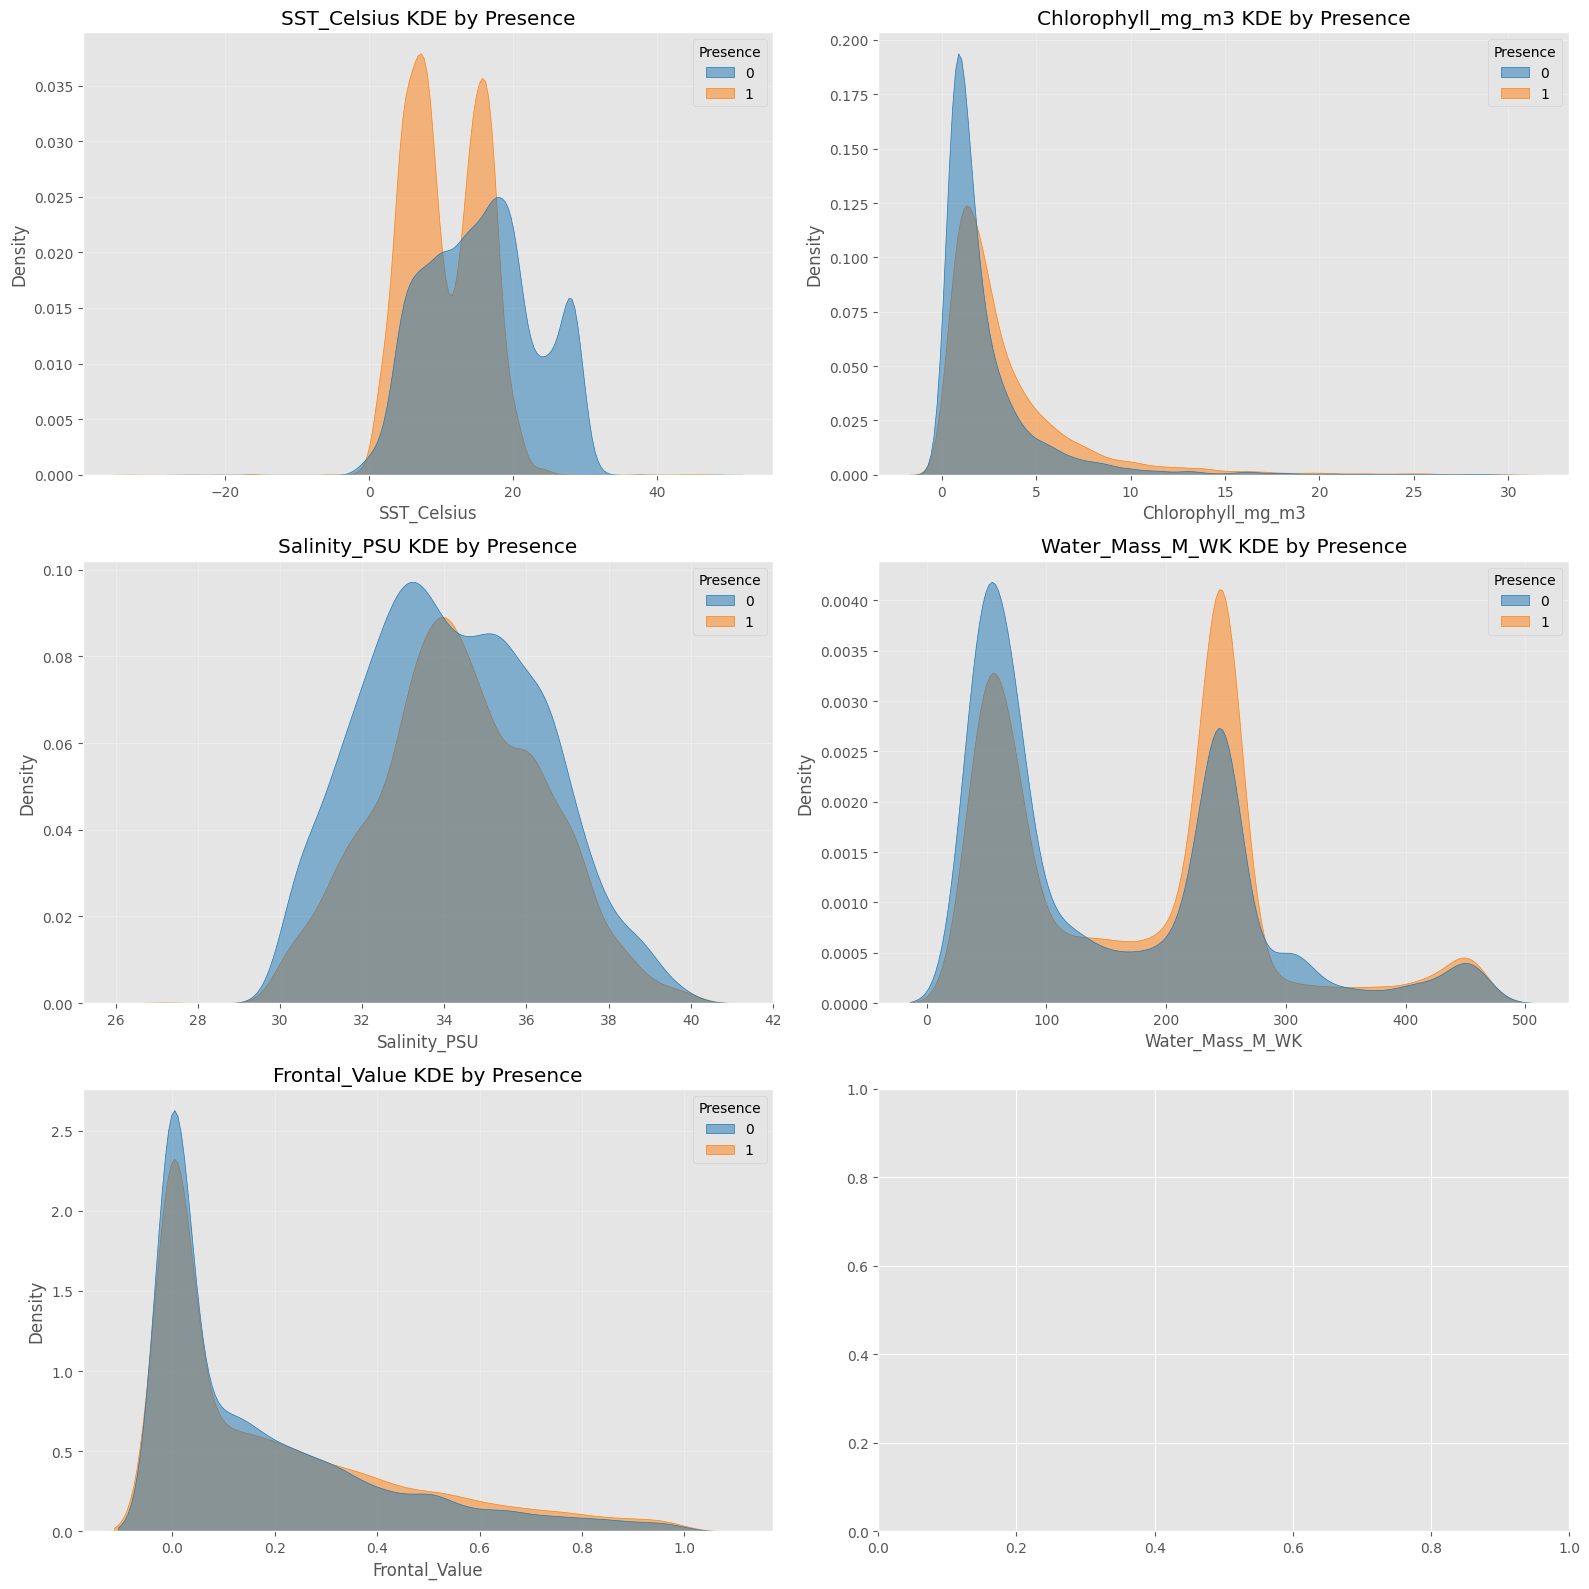

In [235]:
numeric_cols = ['SST_Celsius', 'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK', "Frontal_Value"]

df = df[(df['SST_Celsius'] >= -40) & (df['SST_Celsius'] <= 50)]
df = df[(df['Chlorophyll_mg_m3'] >= 0) & (df['Chlorophyll_mg_m3'] <= 30)]
df = df[(df['Frontal_Value'] >= 0) & (df['Frontal_Value'] <= 1)]

print(f"After outlier removal: {len(df)} rows remaining")

# KDE plots for numeric features
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.kdeplot(data=df, x=col, hue='Presence', ax=ax, fill=True, alpha=0.5, palette=['#1f77b4', '#ff7f0e'])
    ax.set_title(f'{col} KDE by Presence')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

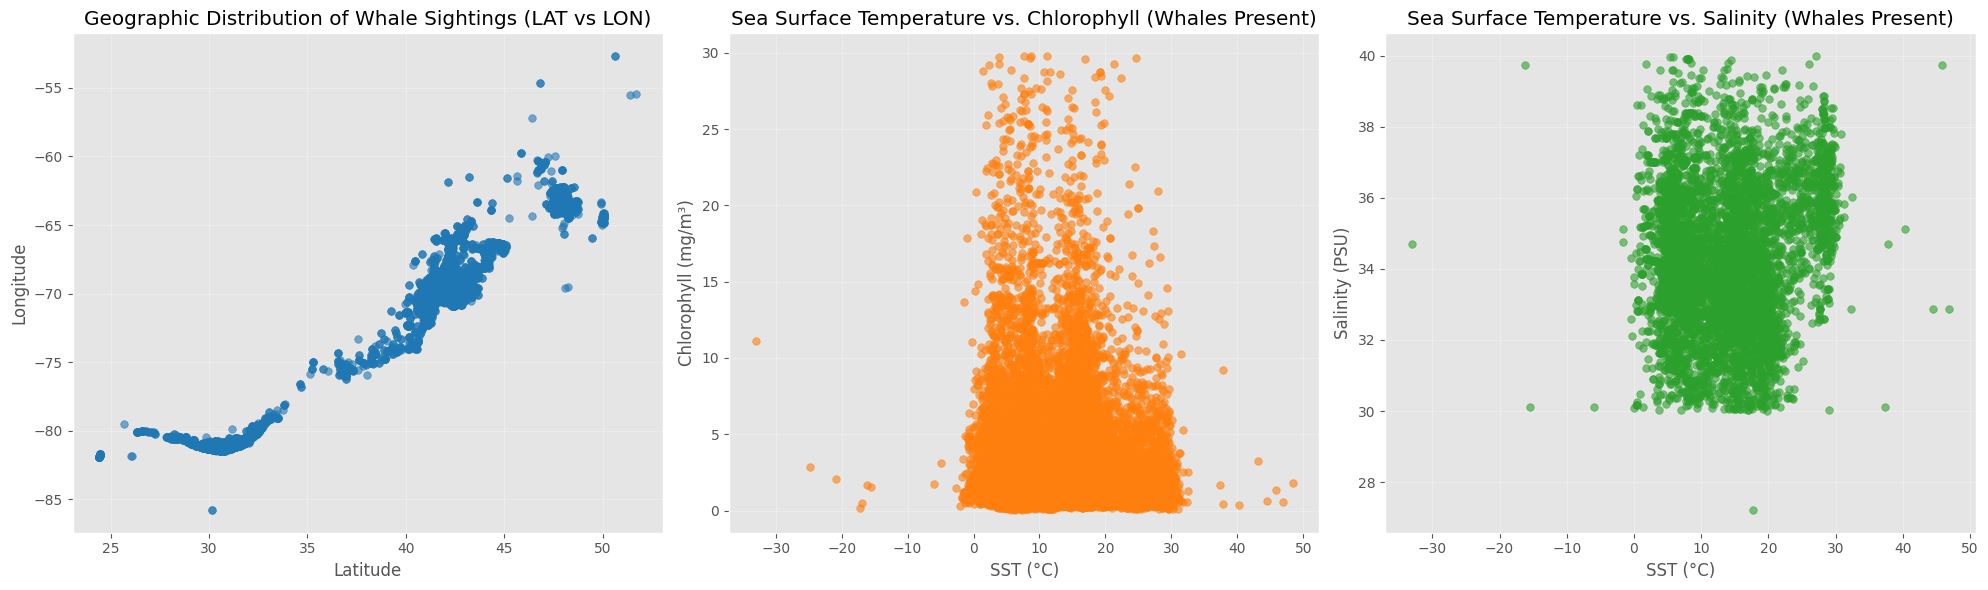

In [236]:
# All three scatter plots in one cell
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Geographic distribution (LAT vs LON)
axes[0].scatter(df['LAT'], df['LON'], alpha=0.6, s=30, color='#1f77b4')
axes[0].set_xlabel('Latitude')
axes[0].set_ylabel('Longitude')
axes[0].set_title('Geographic Distribution of Whale Sightings (LAT vs LON)')
axes[0].grid(alpha=0.3)

# 2. SST vs Chlorophyll relationship
series2 = df[['SST_Celsius', 'Chlorophyll_mg_m3']].dropna()
axes[1].scatter(series2['SST_Celsius'], series2['Chlorophyll_mg_m3'], alpha=0.6, s=30, color='#ff7f0e')
axes[1].set_xlabel('SST (°C)')
axes[1].set_ylabel('Chlorophyll (mg/m³)')
axes[1].set_title('Sea Surface Temperature vs. Chlorophyll (Whales Present)')
axes[1].grid(alpha=0.3)

# 3. SST vs Salinity relationship
series3 = df[['SST_Celsius', 'Salinity_PSU']].dropna()
axes[2].scatter(series3['SST_Celsius'], series3['Salinity_PSU'], alpha=0.6, s=30, color='#2ca02c')
axes[2].set_xlabel('SST (°C)')
axes[2].set_ylabel('Salinity (PSU)')
axes[2].set_title('Sea Surface Temperature vs. Salinity (Whales Present)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [237]:
df_corr = df[['SST_Celsius','Chlorophyll_mg_m3', 
              'Salinity_PSU', 'Water_Mass_M_WK']].dropna().corr()
df_corr

,SST_Celsius,Chlorophyll_mg_m3,Salinity_PSU,Water_Mass_M_WK
SST_Celsius,1.000000,-0.092328,0.101788,-0.303432
Chlorophyll_mg_m3,-0.092328,1.000000,0.060599,-0.003485
Salinity_PSU,0.101788,0.060599,1.000000,0.028694
Water_Mass_M_WK,-0.303432,-0.003485,0.028694,1.000000


<Axes: >

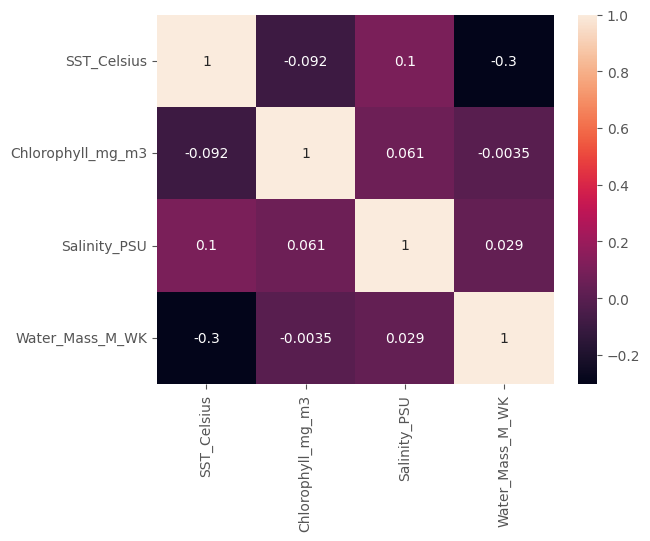

In [238]:
sns.heatmap(df_corr, annot=True)

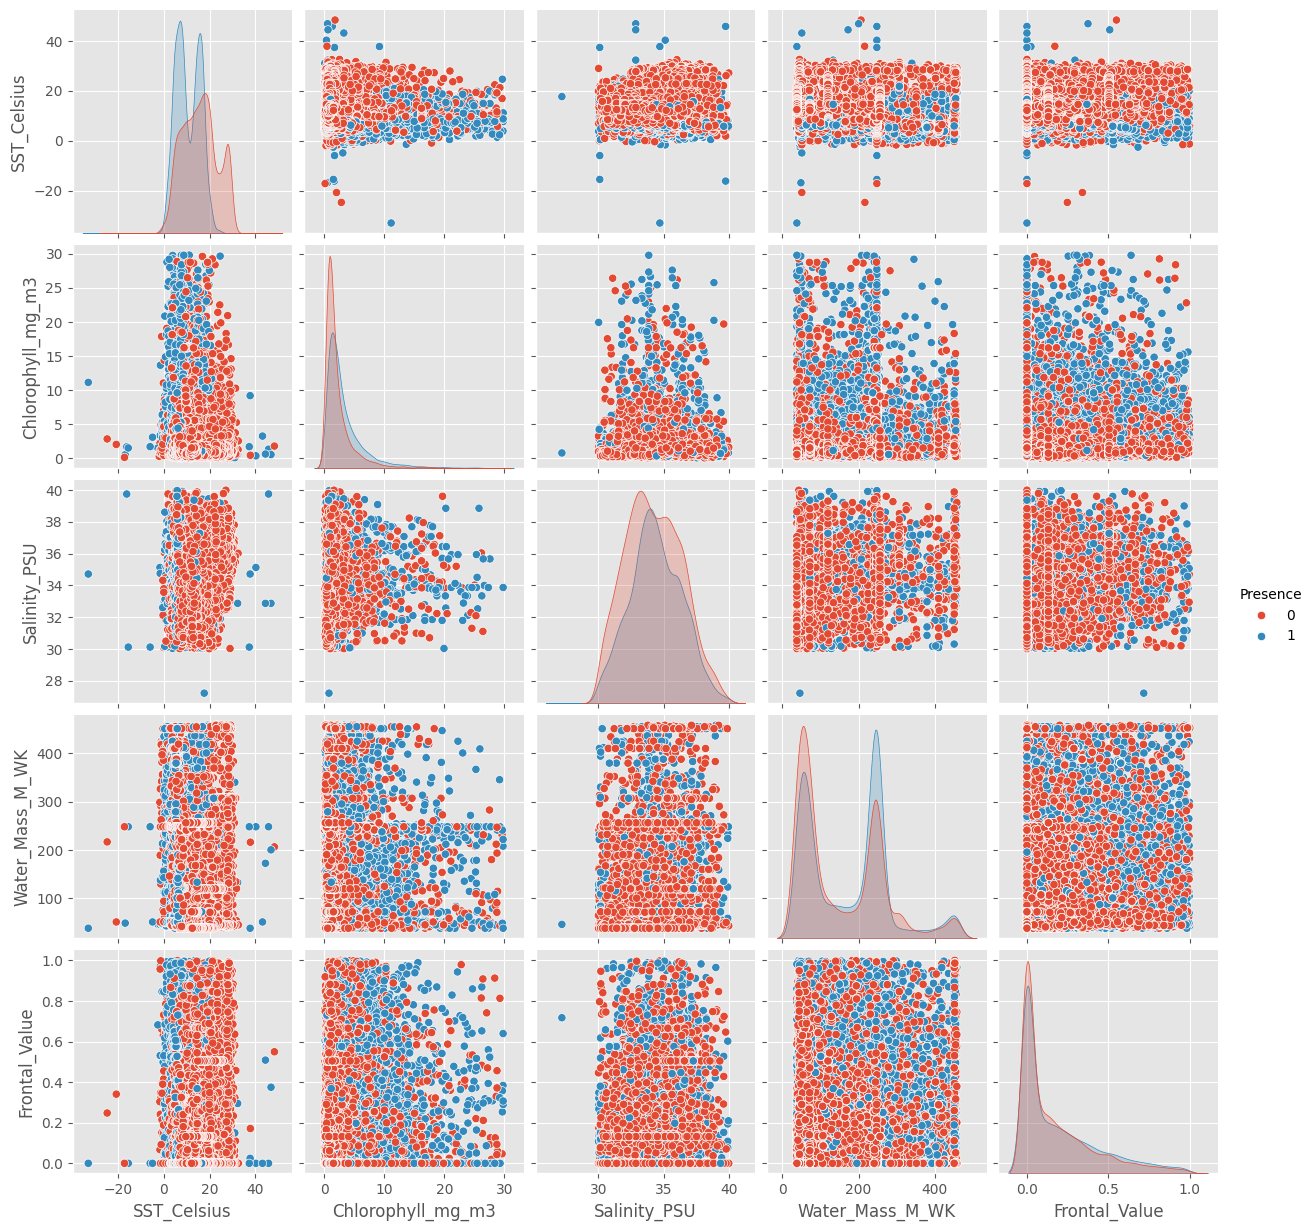

In [239]:
sns.pairplot(df,
             vars=['SST_Celsius', 'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK', 'Frontal_Value'],
            hue='Presence')
plt.show()

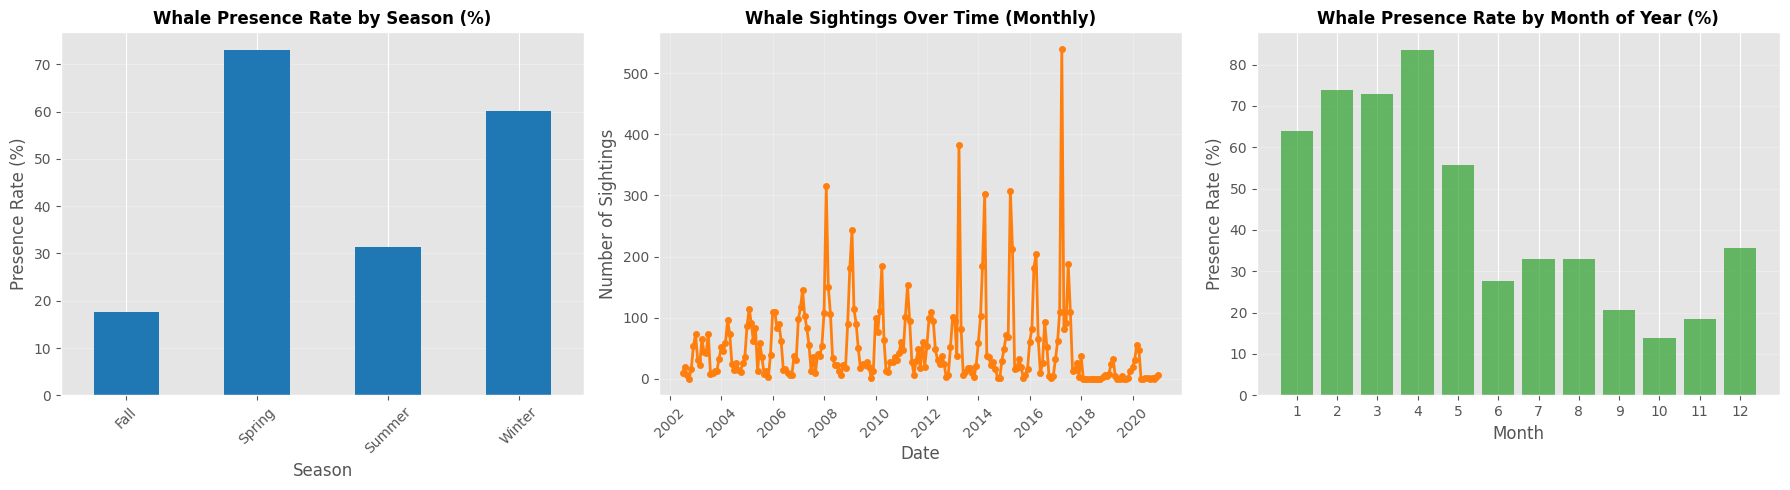


Seasonal Presence Rates:
  Fall: 17.54%
  Spring: 73.12%
  Summer: 31.33%
  Winter: 60.09%


In [240]:
# Create forecasting-focused EDA visualizations
fig = plt.figure(figsize=(18, 5))

# 1. Presence by Season
ax1 = plt.subplot(1, 3, 1)
season_presence = df.groupby('Season')['Presence'].agg(['sum', 'count'])
season_presence['presence_rate'] = season_presence['sum'] / season_presence['count'] * 100
season_presence['presence_rate'].plot(kind='bar', ax=ax1, color='#1f77b4')
ax1.set_title('Whale Presence Rate by Season (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Season')
ax1.set_ylabel('Presence Rate (%)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.grid(alpha=0.3, axis='y')

# 2. Temporal Trend - Sightings over time
ax2 = plt.subplot(1, 3, 2)
df_time = df[df['Presence'] == 1].set_index('SIGHTINGDATE').resample('MS').size()
ax2.plot(df_time.index, df_time.values, linewidth=2, color='#ff7f0e', marker='o', markersize=4)
ax2.set_title('Whale Sightings Over Time (Monthly)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of Sightings')
ax2.grid(alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# 3. Presence by Month
ax3 = plt.subplot(1, 3, 3)
df['Month'] = df['SIGHTINGDATE'].dt.month
month_presence = df.groupby('Month')['Presence'].agg(['sum', 'count'])
month_presence['presence_rate'] = month_presence['sum'] / month_presence['count'] * 100
ax3.bar(month_presence.index, month_presence['presence_rate'], color='#2ca02c', alpha=0.7)
ax3.set_title('Whale Presence Rate by Month of Year (%)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Presence Rate (%)')
ax3.set_xticks(range(1, 13))
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
class_counts = df['Presence'].value_counts()
print("="*70)
print(f"\nSeasonal Presence Rates:")
for season in season_presence.index:
    print(f"  {season}: {season_presence.loc[season, 'presence_rate']:.2f}%")